# Regime Analysis — Data Explorer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

bt = pd.read_parquet('../data/backtest.parquet')
vix_raw = pd.read_parquet('../data/vix_daily.parquet')

# Portfolio-level aggregation
agg = bt.groupby('timestamp').agg(
    funding_pnl=('funding_pnl', 'sum'),
    cost_drag=('cost_drag', 'sum'),
    basis_pnl=('basis_pnl', 'sum'),
    total_pnl=('total_pnl', 'sum'),
    turnover=('turnover', 'sum'),
).sort_index().reset_index()

# Merge VIX onto 8h timestamps (forward-fill daily VIX)
vix_raw['timestamp'] = pd.to_datetime(vix_raw['timestamp']).dt.tz_localize('UTC')
vix_raw = vix_raw.sort_values('timestamp').dropna(subset=['vix'])
agg = pd.merge_asof(agg.sort_values('timestamp'), vix_raw, on='timestamp', direction='backward')

# Regime labels
SPLIT = pd.Timestamp('2021-01-01', tz='UTC')
VIX_THRESH = 25
agg['era'] = np.where(agg['timestamp'] < SPLIT, 'Pre-2021', 'Post-2021')
agg['vix_regime'] = np.where(agg['vix'] <= VIX_THRESH, f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}')
agg['regime_2x2'] = agg['era'] + ' & ' + agg['vix_regime']
agg['cum_pnl'] = agg['total_pnl'].cumsum()

PERIODS_PER_YEAR = 365.25 * 3
print(f"Periods: {len(agg)}, VIX coverage: {agg['vix'].notna().mean():.1%}")
print(f"VIX>{VIX_THRESH}: {(agg['vix']>VIX_THRESH).sum()} periods ({(agg['vix']>VIX_THRESH).mean():.1%})")
print(f"Pre-2021: {(agg['era']=='Pre-2021').sum()}, Post-2021: {(agg['era']=='Post-2021').sum()}")

Periods: 6801, VIX coverage: 100.0%
VIX>25: 1467 periods (21.6%)
Pre-2021: 1053, Post-2021: 5748


## 1. VIX Time Series with Regime Shading

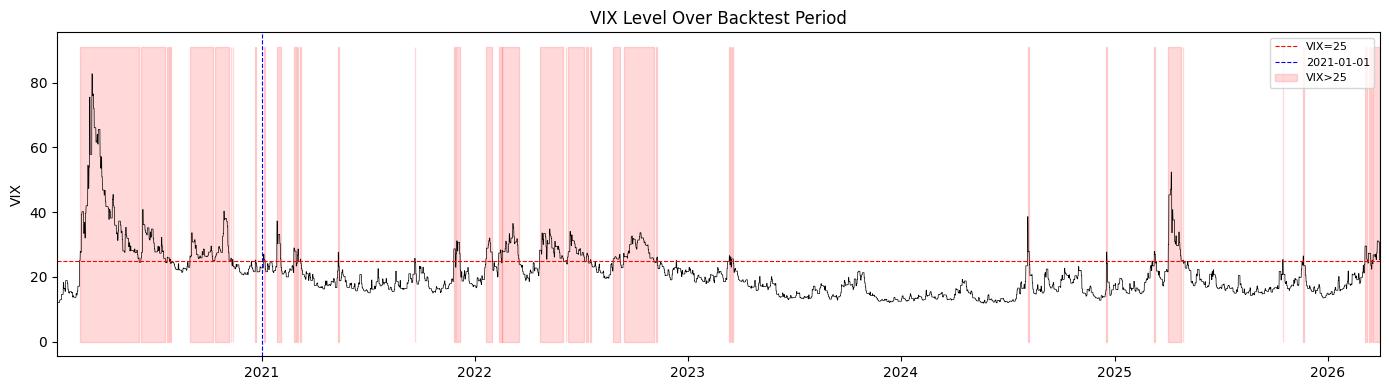

In [2]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(agg['timestamp'], agg['vix'], linewidth=0.5, color='black')
ax.axhline(VIX_THRESH, color='red', linestyle='--', linewidth=0.8, label=f'VIX={VIX_THRESH}')
ax.axvline(SPLIT, color='blue', linestyle='--', linewidth=0.8, label='2021-01-01')

# Shade high-VIX periods
high = agg['vix'] > VIX_THRESH
ax.fill_between(agg['timestamp'], 0, agg['vix'].max()*1.1,
                where=high, alpha=0.15, color='red', label=f'VIX>{VIX_THRESH}')

ax.set_ylabel('VIX')
ax.set_title('VIX Level Over Backtest Period')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(agg['timestamp'].min(), agg['timestamp'].max())
plt.tight_layout()
plt.show()

## 2. Cumulative P&L by Era (Pre vs Post 2021)

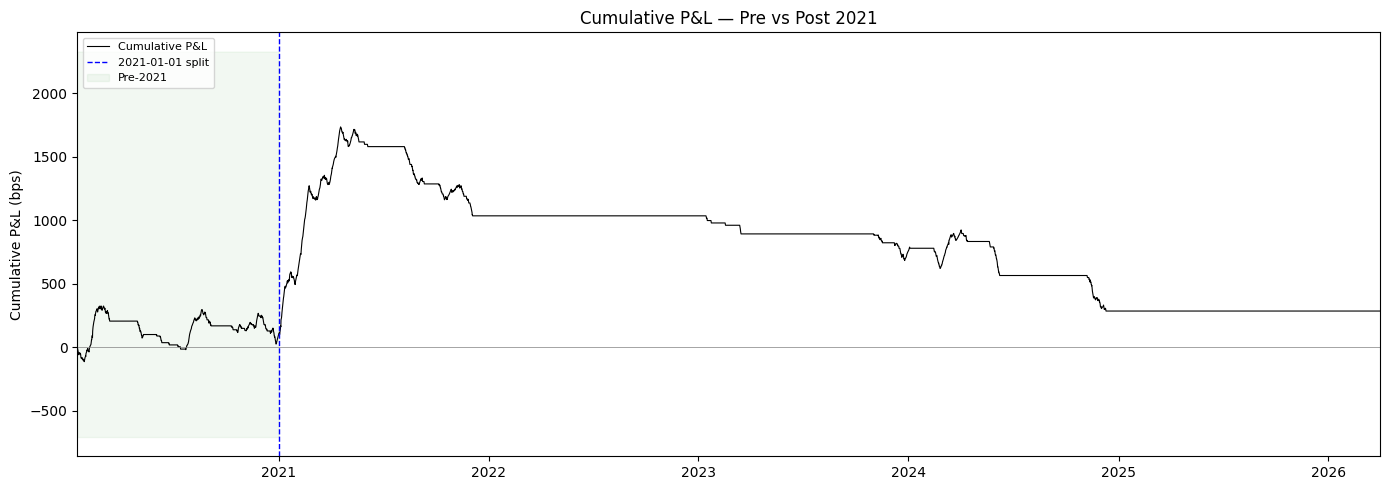

Pre-2021: Sharpe=0.611, Total=104.0bps, Ann=108.2bps/yr, N=1053
Post-2021: Sharpe=0.309, Total=181.6bps, Ann=34.6bps/yr, N=5748


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(agg['timestamp'], agg['cum_pnl'] * 10_000, color='black', linewidth=0.8, label='Cumulative P&L')
ax.axvline(SPLIT, color='blue', linestyle='--', linewidth=1, label='2021-01-01 split')
ax.axhline(0, color='grey', linewidth=0.5)

# Shade eras
pre_mask = agg['timestamp'] < SPLIT
ax.fill_between(agg['timestamp'], ax.get_ylim()[0]-500, ax.get_ylim()[1]+500,
                where=pre_mask, alpha=0.05, color='green', label='Pre-2021')

ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Cumulative P&L — Pre vs Post 2021')
ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(agg['timestamp'].min(), agg['timestamp'].max())
plt.tight_layout()
plt.show()

# Stats
for era in ['Pre-2021', 'Post-2021']:
    sub = agg[agg['era'] == era]
    pnl = sub['total_pnl'].values
    sharpe = pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0
    total = pnl.sum() * 10_000
    yrs = len(pnl) / PERIODS_PER_YEAR
    print(f"{era}: Sharpe={sharpe:.3f}, Total={total:.1f}bps, Ann={total/yrs:.1f}bps/yr, N={len(pnl)}")

## 3. Cumulative P&L Colored by VIX Regime

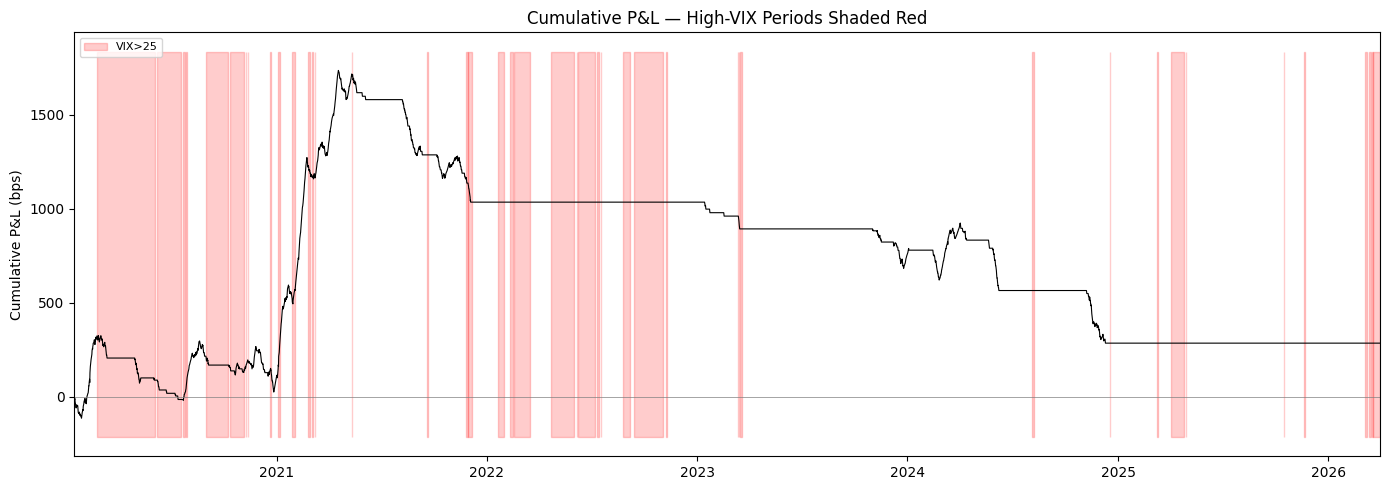

In [4]:
# Cumulative P&L with VIX>25 periods shaded in red
fig, ax = plt.subplots(figsize=(14, 5))
cum = agg['total_pnl'].cumsum() * 10_000
ax.plot(agg['timestamp'], cum, color='black', linewidth=0.8)
ax.axhline(0, color='grey', linewidth=0.5)

high = agg['vix'] > VIX_THRESH
ax.fill_between(agg['timestamp'], cum.min()-100, cum.max()+100,
                where=high, alpha=0.2, color='red', label=f'VIX>{VIX_THRESH}')

ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Cumulative P&L — High-VIX Periods Shaded Red')
ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(agg['timestamp'].min(), agg['timestamp'].max())
plt.tight_layout()
plt.show()

## 4. Separate Cumulative P&L Curves: Low-VIX vs High-VIX

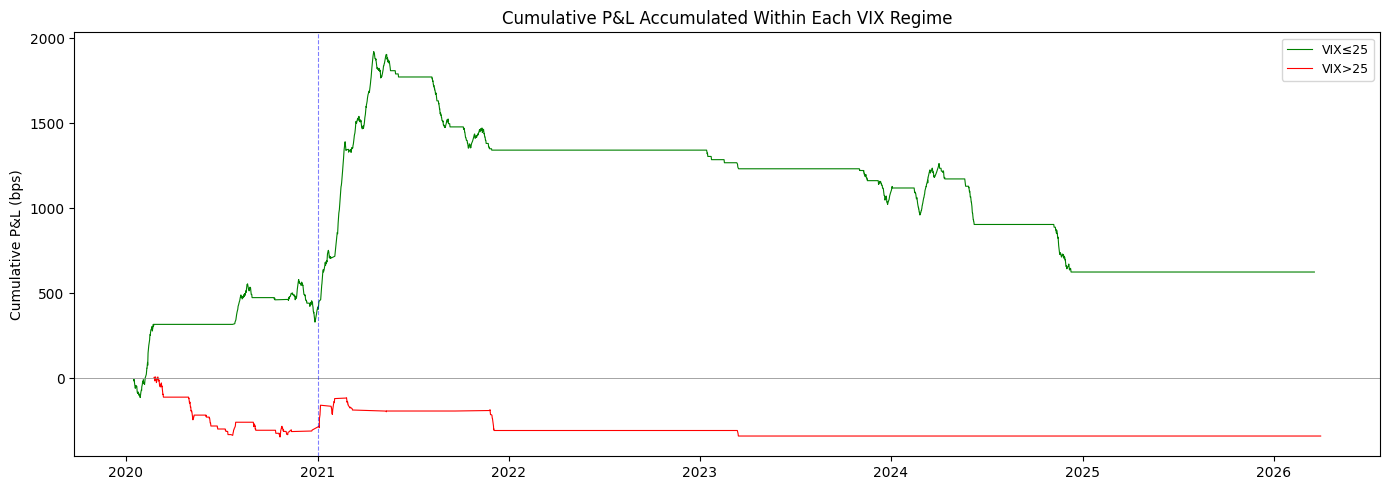

In [5]:
# Accumulate P&L separately for each VIX regime
fig, ax = plt.subplots(figsize=(14, 5))

for regime, color, ls in [('VIX≤25', 'green', '-'), ('VIX>25', 'red', '-')]:
    mask = agg['vix_regime'] == regime
    sub = agg[mask].copy()
    sub['cum'] = sub['total_pnl'].cumsum() * 10_000
    ax.plot(sub['timestamp'], sub['cum'], color=color, linewidth=0.8, label=regime)

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(SPLIT, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Cumulative P&L Accumulated Within Each VIX Regime')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Per-Regime Performance Table

In [6]:
regime_df = pd.read_csv('../output/regime_analysis.csv')
display_cols = ['regime', 'sharpe', 'total_bps', 'annual_bps', 'max_dd_bps',
                'win_rate', 'active_periods', 'pct_time_in_carry', 'n_periods']
styled = regime_df[display_cols].copy()
styled['sharpe'] = styled['sharpe'].map('{:.3f}'.format)
styled['total_bps'] = styled['total_bps'].map('{:.1f}'.format)
styled['annual_bps'] = styled['annual_bps'].map('{:.1f}'.format)
styled['max_dd_bps'] = styled['max_dd_bps'].map('{:.1f}'.format)
styled['win_rate'] = styled['win_rate'].map('{:.1%}'.format)
styled['pct_time_in_carry'] = styled['pct_time_in_carry'].map('{:.1%}'.format)
styled

,regime,sharpe,total_bps,annual_bps,max_dd_bps,win_rate,active_periods,pct_time_in_carry,n_periods
0,Full Sample,0.370,285.6,46.0,-1448.6,61.2%,1505,22.1%,6801
1,Pre-2021,0.611,104.0,108.2,-343.7,61.1%,489,46.4%,1053
2,Post-2021,0.309,181.6,34.6,-1448.6,61.2%,1016,17.7%,5748
3,VIX <= 25,1.017,624.8,128.4,-1295.6,63.4%,1267,23.8%,5334
4,VIX > 25,-2.174,-339.2,-253.4,-353.4,49.6%,238,16.2%,1467
5,Pre-2021 & VIX <= 25,4.687,408.2,1104.5,-250.2,65.8%,322,79.5%,405
6,Pre-2021 & VIX > 25,-4.140,-304.2,-514.4,-353.4,52.1%,167,25.8%,648
7,Post-2021 & VIX <= 25,0.429,216.6,48.2,-1295.6,62.5%,945,19.2%,4929
8,Post-2021 & VIX > 25,-0.427,-35.0,-46.8,-225.0,43.7%,71,8.7%,819


## 6. 2×2 Sharpe Heatmap (Era × VIX)

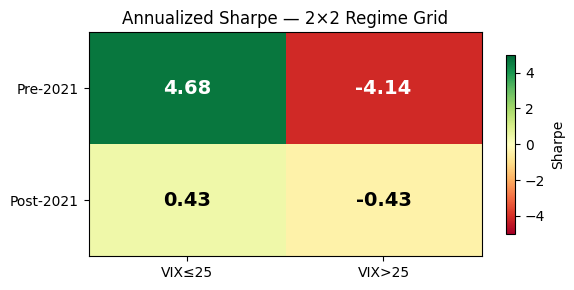

In [7]:
# Compute Sharpe for each 2x2 cell
def sharpe(pnl):
    return pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0

grid = agg.groupby(['era', 'vix_regime'])['total_pnl'].apply(sharpe).unstack()
grid = grid.reindex(index=['Pre-2021', 'Post-2021'], columns=[f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}'])

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(grid.values, cmap='RdYlGn', aspect='auto', vmin=-5, vmax=5)
ax.set_xticks([0, 1])
ax.set_xticklabels(grid.columns)
ax.set_yticks([0, 1])
ax.set_yticklabels(grid.index)

for i in range(2):
    for j in range(2):
        val = grid.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if abs(val) > 2.5 else 'black')

ax.set_title('Annualized Sharpe — 2×2 Regime Grid')
fig.colorbar(im, ax=ax, shrink=0.8, label='Sharpe')
plt.tight_layout()
plt.show()

## 7. P&L Decomposition by VIX Regime (Funding vs Cost vs Basis)

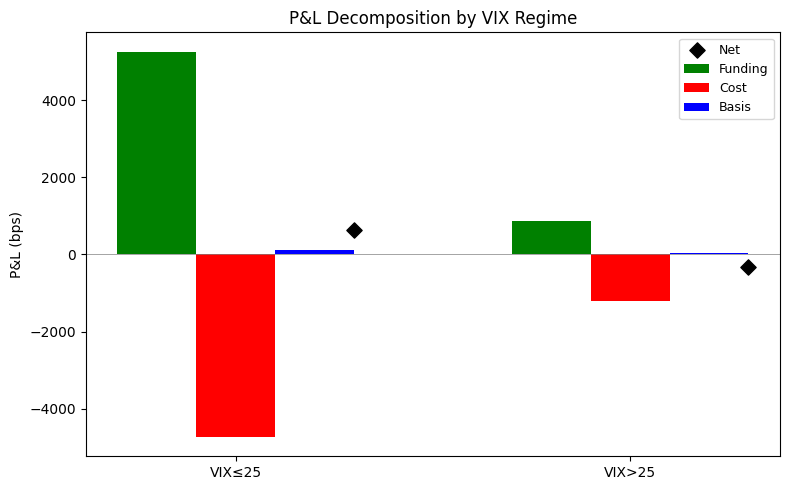

            funding_pnl  cost_drag  basis_pnl  total_pnl
vix_regime                                              
VIX≤25           5258.5    -4735.7      102.1      624.8
VIX>25            853.2    -1218.8       26.5     -339.2


In [8]:
# Stacked bar: funding, cost, basis per VIX regime
decomp = agg.groupby('vix_regime')[['funding_pnl', 'cost_drag', 'basis_pnl', 'total_pnl']].sum() * 10_000
decomp = decomp.reindex([f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}'])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(decomp))
w = 0.2
ax.bar(x - w, decomp['funding_pnl'], width=w, color='green', label='Funding')
ax.bar(x, decomp['cost_drag'], width=w, color='red', label='Cost')
ax.bar(x + w, decomp['basis_pnl'], width=w, color='blue', label='Basis')
# Total as marker
ax.scatter(x + 1.5*w, decomp['total_pnl'], color='black', zorder=5, s=60, marker='D', label='Net')
ax.axhline(0, color='grey', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(decomp.index)
ax.set_ylabel('P&L (bps)')
ax.set_title('P&L Decomposition by VIX Regime')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(decomp.round(1))

## 8. Per-Period P&L Distribution by VIX Regime

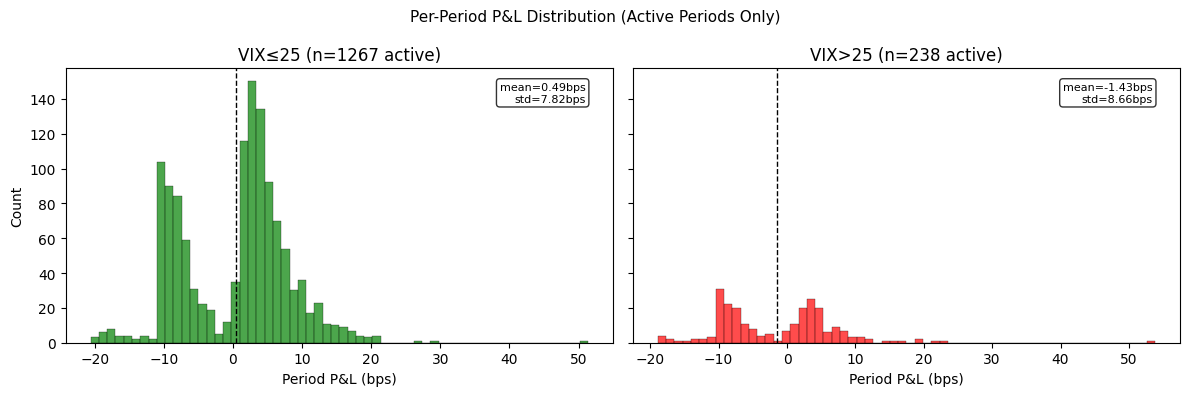

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, regime, color in zip(axes, [f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}'], ['green', 'red']):
    sub = agg[agg['vix_regime'] == regime]
    active = sub[sub['total_pnl'] != 0]['total_pnl'] * 10_000
    ax.hist(active, bins=60, color=color, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.axvline(active.mean(), color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{regime} (n={len(active)} active)')
    ax.set_xlabel('Period P&L (bps)')
    mn = active.mean()
    ax.text(0.95, 0.95, f'mean={mn:.2f}bps\nstd={active.std():.2f}bps',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_ylabel('Count')
fig.suptitle('Per-Period P&L Distribution (Active Periods Only)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Rolling 90-Day Sharpe Colored by VIX Regime

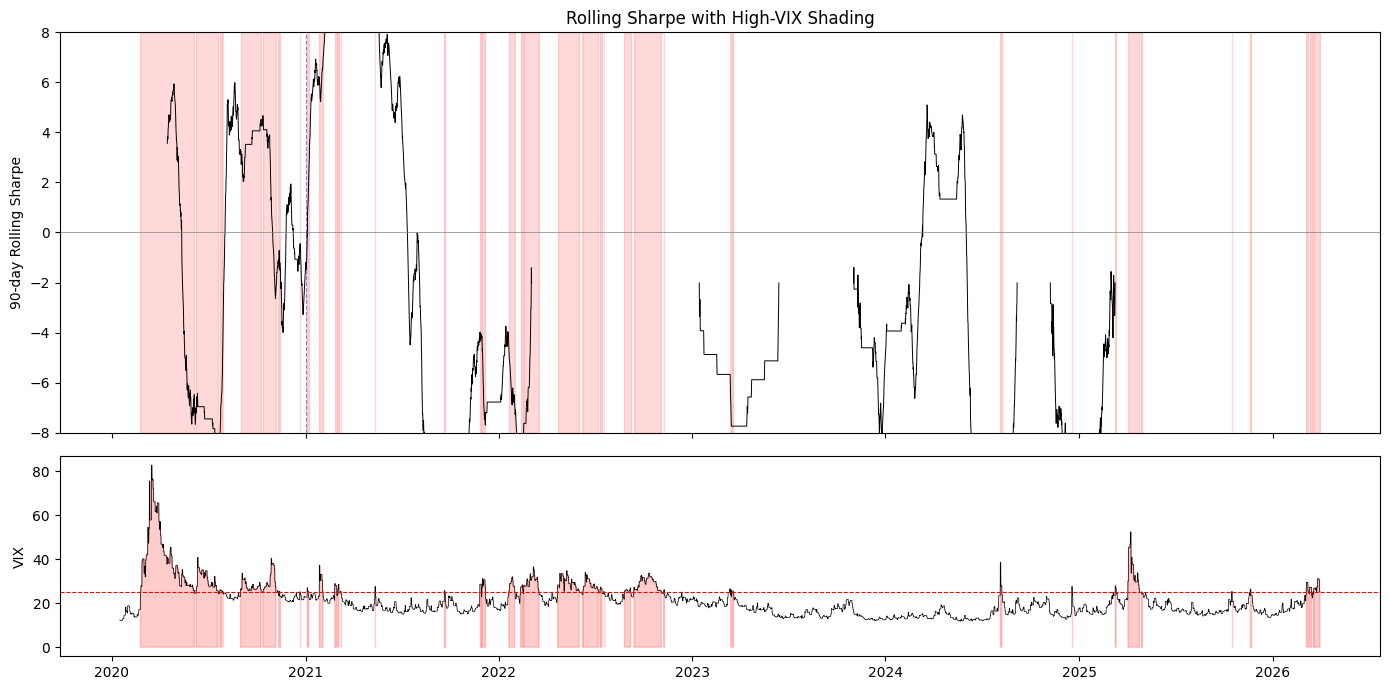

In [10]:
window = int(90 * 3)  # 90 days of 8h periods
roll_mean = agg['total_pnl'].rolling(window).mean()
roll_std = agg['total_pnl'].rolling(window).std()
roll_sharpe = (roll_mean / roll_std * np.sqrt(PERIODS_PER_YEAR))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top: rolling Sharpe
ax = axes[0]
ax.plot(agg['timestamp'], roll_sharpe, color='black', linewidth=0.7)
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(SPLIT, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
# Shade high VIX
high = agg['vix'] > VIX_THRESH
ax.fill_between(agg['timestamp'], -8, 8, where=high, alpha=0.15, color='red')
ax.set_ylabel('90-day Rolling Sharpe')
ax.set_title('Rolling Sharpe with High-VIX Shading')
ax.set_ylim(-8, 8)

# Bottom: VIX level
ax2 = axes[1]
ax2.plot(agg['timestamp'], agg['vix'], color='black', linewidth=0.5)
ax2.axhline(VIX_THRESH, color='red', linestyle='--', linewidth=0.8)
ax2.fill_between(agg['timestamp'], 0, agg['vix'], where=high, alpha=0.2, color='red')
ax2.set_ylabel('VIX')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

## 10. Win Rate by Regime

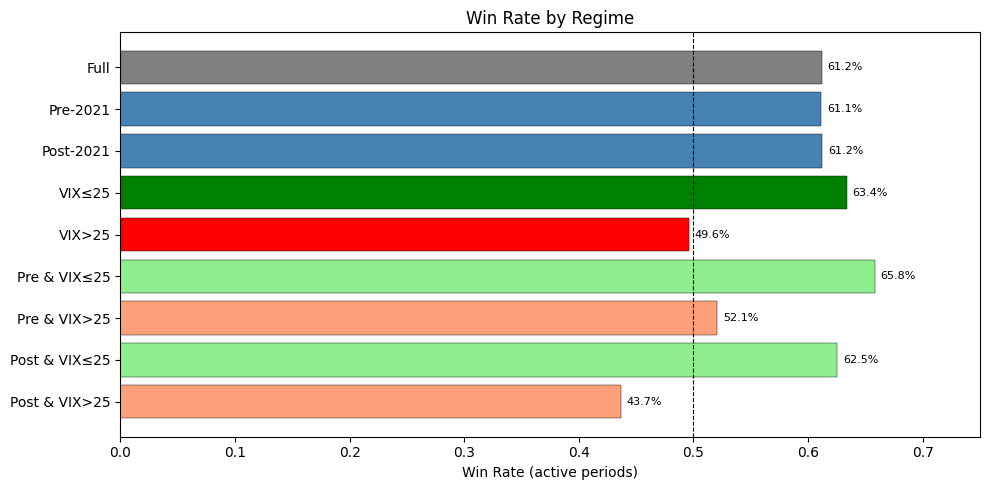

In [11]:
# Win rate = fraction of active (nonzero P&L) periods that are positive
labels = ['Full', 'Pre-2021', 'Post-2021', f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}',
          f'Pre & VIX≤{VIX_THRESH}', f'Pre & VIX>{VIX_THRESH}',
          f'Post & VIX≤{VIX_THRESH}', f'Post & VIX>{VIX_THRESH}']
masks = [
    pd.Series(True, index=agg.index),
    agg['era'] == 'Pre-2021',
    agg['era'] == 'Post-2021',
    agg['vix_regime'] == f'VIX≤{VIX_THRESH}',
    agg['vix_regime'] == f'VIX>{VIX_THRESH}',
    (agg['era'] == 'Pre-2021') & (agg['vix_regime'] == f'VIX≤{VIX_THRESH}'),
    (agg['era'] == 'Pre-2021') & (agg['vix_regime'] == f'VIX>{VIX_THRESH}'),
    (agg['era'] == 'Post-2021') & (agg['vix_regime'] == f'VIX≤{VIX_THRESH}'),
    (agg['era'] == 'Post-2021') & (agg['vix_regime'] == f'VIX>{VIX_THRESH}'),
]

win_rates = []
for m in masks:
    sub = agg.loc[m]
    active = sub[sub['total_pnl'] != 0]['total_pnl']
    wr = (active > 0).mean() if len(active) > 0 else 0
    win_rates.append(wr)

colors = ['grey', 'steelblue', 'steelblue', 'green', 'red',
          'lightgreen', 'lightsalmon', 'lightgreen', 'lightsalmon']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(labels)), win_rates, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='50% (coin flip)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Win Rate (active periods)')
ax.set_title('Win Rate by Regime')
ax.invert_yaxis()
for i, wr in enumerate(win_rates):
    ax.text(wr + 0.005, i, f'{wr:.1%}', va='center', fontsize=8)
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

## 11. VIX vs Per-Period P&L Scatter

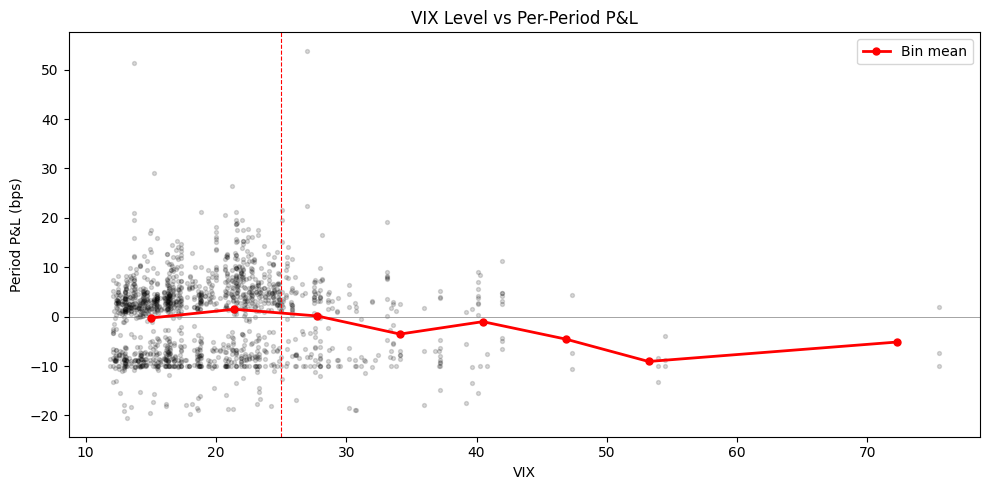

Correlation(VIX, period P&L): -0.0384


In [12]:
# Scatter: VIX level vs period P&L (active periods only)
active = agg[agg['total_pnl'] != 0].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(active['vix'], active['total_pnl'] * 10_000, alpha=0.15, s=8, color='black')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(VIX_THRESH, color='red', linestyle='--', linewidth=0.8)

# Binned means
bins = pd.cut(active['vix'], bins=10)
binned = active.groupby(bins, observed=True)['total_pnl'].mean() * 10_000
bin_centers = [(b.left + b.right) / 2 for b in binned.index]
ax.plot(bin_centers, binned.values, color='red', linewidth=2, marker='o', markersize=5, label='Bin mean')

ax.set_xlabel('VIX')
ax.set_ylabel('Period P&L (bps)')
ax.set_title('VIX Level vs Per-Period P&L')
ax.legend()
plt.tight_layout()
plt.show()

# Correlation
corr = active[['vix', 'total_pnl']].corr().iloc[0, 1]
print(f"Correlation(VIX, period P&L): {corr:.4f}")

## 12. Drawdown Analysis by VIX Regime

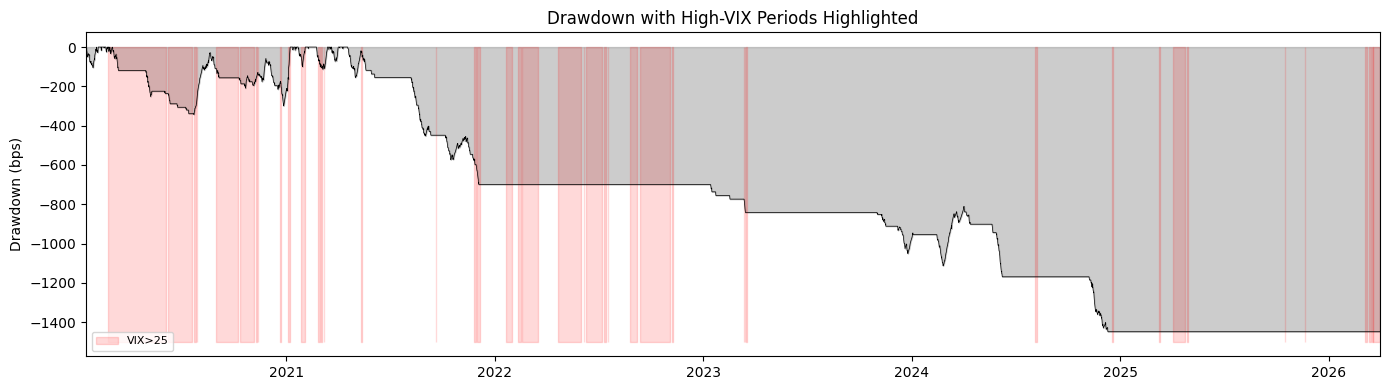

P&L during VIX≤25: +624.8 bps
P&L during VIX>25: -339.2 bps
High-VIX accounts for 54% of low-VIX gains eaten back


In [13]:
# Drawdown curve with VIX regime shading
cum = agg['total_pnl'].cumsum()
peak = cum.cummax()
dd = (cum - peak) * 10_000

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(agg['timestamp'], dd, 0, color='grey', alpha=0.4)
ax.plot(agg['timestamp'], dd, color='black', linewidth=0.5)

# Overlay red ticks where VIX > 25
high = agg['vix'] > VIX_THRESH
ax.fill_between(agg['timestamp'], dd.min()-50, 0, where=high, alpha=0.15, color='red', label=f'VIX>{VIX_THRESH}')

ax.set_ylabel('Drawdown (bps)')
ax.set_title('Drawdown with High-VIX Periods Highlighted')
ax.legend(loc='lower left', fontsize=8)
ax.set_xlim(agg['timestamp'].min(), agg['timestamp'].max())
plt.tight_layout()
plt.show()

# What % of total drawdown occurred during high-VIX?
dd_high_vix = agg.loc[high, 'total_pnl'].sum() * 10_000
dd_total = agg['total_pnl'].sum() * 10_000
pnl_low = agg.loc[~high, 'total_pnl'].sum() * 10_000
print(f"P&L during VIX≤25: {pnl_low:+.1f} bps")
print(f"P&L during VIX>25: {dd_high_vix:+.1f} bps")
print(f"High-VIX accounts for {abs(dd_high_vix)/abs(pnl_low)*100:.0f}% of low-VIX gains eaten back")

## 13. Counterfactual: P&L With VIX Filter (Suppress Carry When VIX > 25)

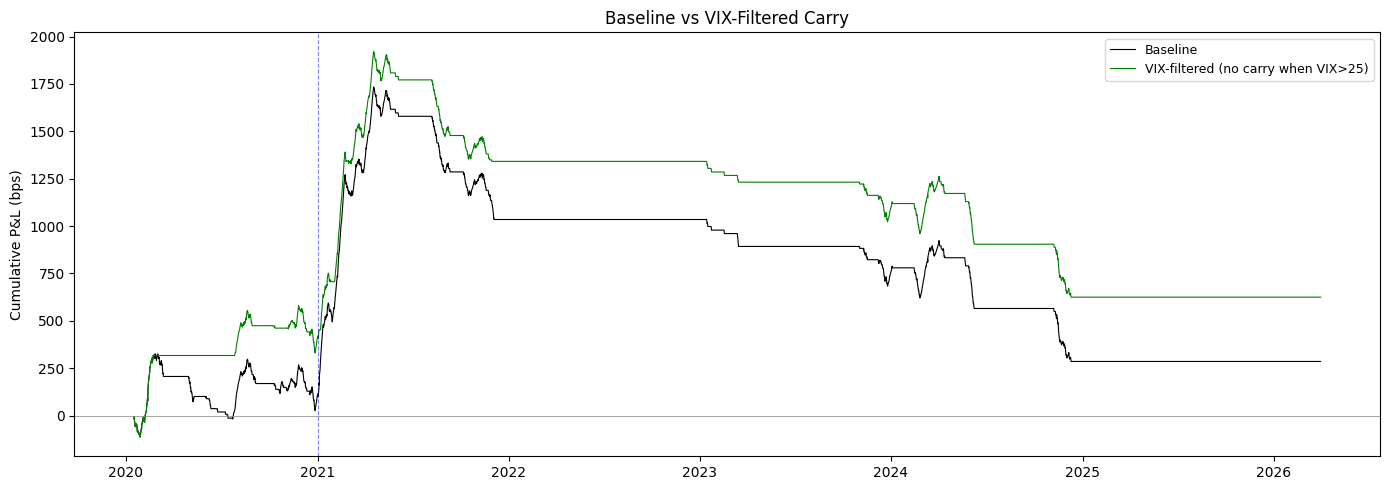

  Baseline: Sharpe=0.370, Total=285.6bps, Ann=46.0bps/yr, MaxDD=-1448.6bps
  VIX-filtered: Sharpe=0.900, Total=624.8bps, Ann=100.7bps/yr, MaxDD=-1295.6bps

  Note: VIX filter is in-sample. VIX=25 threshold was chosen ex ante (convention), not optimized.


In [14]:
# Counterfactual: zero out P&L during VIX>25 (as if we flat the position)
# This is the upper bound — real filter would still incur exit/re-entry cost
agg_filtered = agg.copy()
agg_filtered.loc[agg_filtered['vix'] > VIX_THRESH, 'total_pnl'] = 0

cum_orig = agg['total_pnl'].cumsum() * 10_000
cum_filt = agg_filtered['total_pnl'].cumsum() * 10_000

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(agg['timestamp'], cum_orig, color='black', linewidth=0.8, label='Baseline')
ax.plot(agg['timestamp'], cum_filt, color='green', linewidth=0.8, label='VIX-filtered (no carry when VIX>25)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(SPLIT, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Baseline vs VIX-Filtered Carry')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Metrics comparison
pnl_orig = agg['total_pnl'].values
pnl_filt = agg_filtered['total_pnl'].values
n = len(pnl_orig)
yrs = n / PERIODS_PER_YEAR

def quick_metrics(pnl, label):
    s = pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0
    cum = np.cumsum(pnl)
    dd = (cum - np.maximum.accumulate(cum)).min() * 10_000
    total = cum[-1] * 10_000
    print(f"  {label}: Sharpe={s:.3f}, Total={total:.1f}bps, Ann={total/yrs:.1f}bps/yr, MaxDD={dd:.1f}bps")

quick_metrics(pnl_orig, 'Baseline')
quick_metrics(pnl_filt, 'VIX-filtered')
print(f"\n  Note: VIX filter is in-sample. VIX=25 threshold was chosen ex ante (convention), not optimized.")

## 14. Funding Rate Distribution by VIX Regime

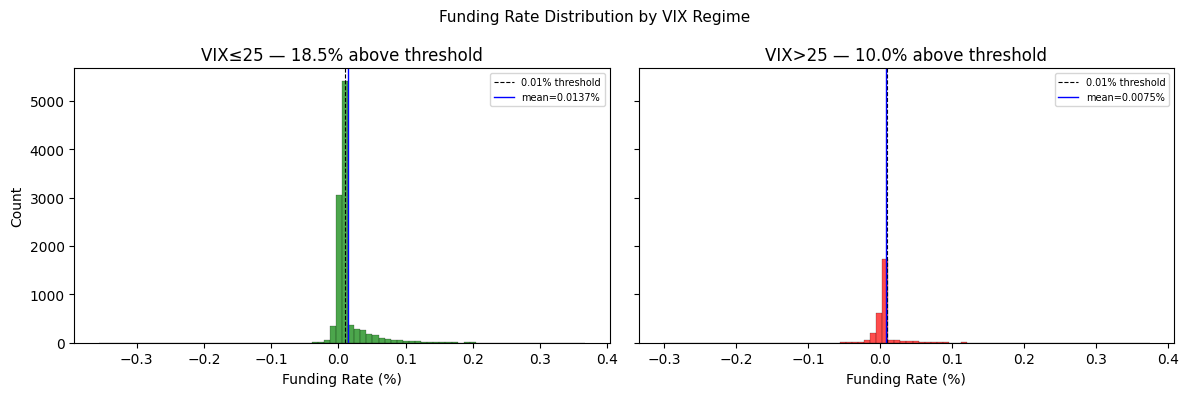

VIX≤25: mean funding=0.0137%, median=0.0100%, above threshold=18.5%
VIX>25: mean funding=0.0075%, median=0.0100%, above threshold=10.0%


In [15]:
# Merge VIX onto per-asset backtest data to look at funding rates by regime
bt_vix = pd.merge_asof(bt.sort_values('timestamp'), vix_raw.sort_values('timestamp'),
                       on='timestamp', direction='backward')
bt_vix['vix_regime'] = np.where(bt_vix['vix'] <= VIX_THRESH, f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, regime, color in zip(axes, [f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}'], ['green', 'red']):
    sub = bt_vix[bt_vix['vix_regime'] == regime]
    fr = sub['funding_rate'] * 100  # to percent
    ax.hist(fr, bins=80, color=color, alpha=0.7, edgecolor='black', linewidth=0.2)
    ax.axvline(0.01, color='black', linestyle='--', linewidth=0.8, label='0.01% threshold')
    ax.axvline(fr.mean(), color='blue', linestyle='-', linewidth=1, label=f'mean={fr.mean():.4f}%')
    above = (sub['funding_rate'] > 0.0001).mean()
    ax.set_title(f'{regime} — {above:.1%} above threshold')
    ax.set_xlabel('Funding Rate (%)')
    ax.legend(fontsize=7)
axes[0].set_ylabel('Count')
fig.suptitle('Funding Rate Distribution by VIX Regime', fontsize=11)
plt.tight_layout()
plt.show()

# Mean funding rate comparison
for reg in [f'VIX≤{VIX_THRESH}', f'VIX>{VIX_THRESH}']:
    sub = bt_vix[bt_vix['vix_regime'] == reg]
    print(f"{reg}: mean funding={sub['funding_rate'].mean()*100:.4f}%, "
          f"median={sub['funding_rate'].median()*100:.4f}%, "
          f"above threshold={(sub['funding_rate']>0.0001).mean():.1%}")

## 15. Monthly P&L Heatmap with VIX Regime Overlay

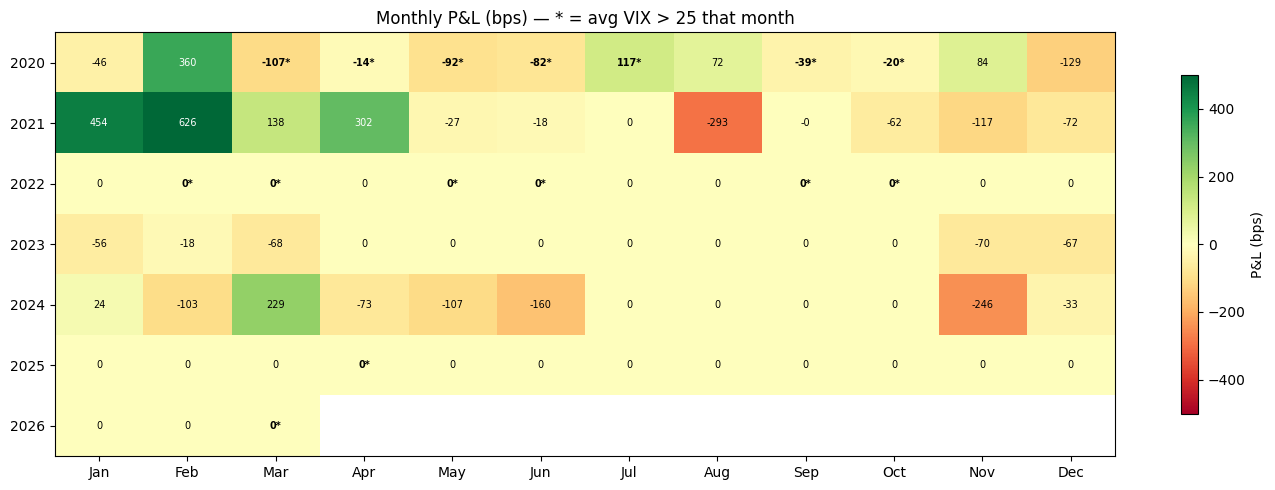

In [16]:
# Monthly P&L heatmap: year x month, with hatching where monthly avg VIX > 25
agg['year'] = agg['timestamp'].dt.year
agg['month'] = agg['timestamp'].dt.month

monthly_pnl = agg.groupby(['year', 'month'])['total_pnl'].sum() * 10_000
monthly_vix = agg.groupby(['year', 'month'])['vix'].mean()

years = sorted(agg['year'].unique())
months = list(range(1, 13))
pnl_grid = np.full((len(years), 12), np.nan)
vix_grid = np.full((len(years), 12), np.nan)

for i, y in enumerate(years):
    for j, m in enumerate(months):
        if (y, m) in monthly_pnl.index:
            pnl_grid[i, j] = monthly_pnl[(y, m)]
            vix_grid[i, j] = monthly_vix[(y, m)]

fig, ax = plt.subplots(figsize=(14, 5))
vmax = np.nanmax(np.abs(pnl_grid)) * 0.8
im = ax.imshow(pnl_grid, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

# Annotate with P&L value; bold border for high-VIX months
for i in range(len(years)):
    for j in range(12):
        if not np.isnan(pnl_grid[i, j]):
            val = pnl_grid[i, j]
            color = 'white' if abs(val) > vmax * 0.6 else 'black'
            weight = 'bold' if not np.isnan(vix_grid[i, j]) and vix_grid[i, j] > VIX_THRESH else 'normal'
            marker = '*' if not np.isnan(vix_grid[i, j]) and vix_grid[i, j] > VIX_THRESH else ''
            ax.text(j, i, f'{val:.0f}{marker}', ha='center', va='center',
                    fontsize=7, color=color, fontweight=weight)

ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years)
ax.set_title('Monthly P&L (bps) — * = avg VIX > 25 that month')
fig.colorbar(im, ax=ax, shrink=0.8, label='P&L (bps)')
plt.tight_layout()
plt.show()

## 16. VIX Threshold Sensitivity — What If We Used a Different Cutoff?

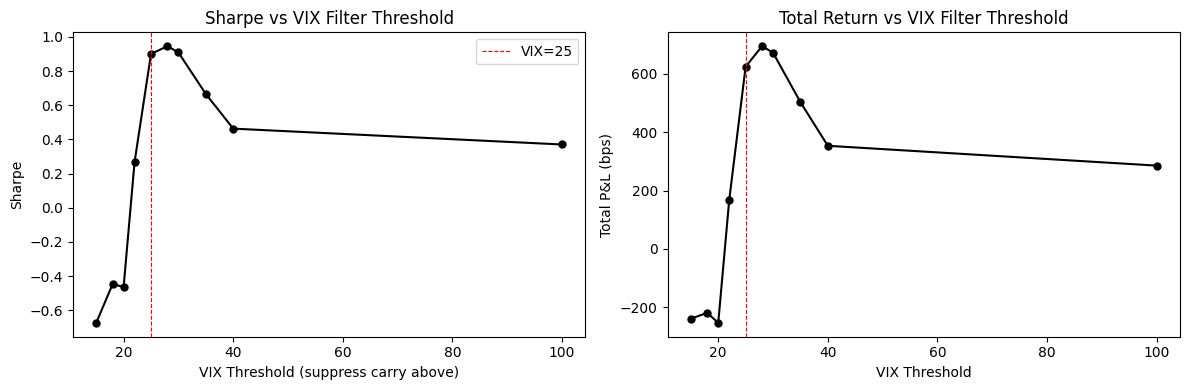

 vix_threshold    sharpe   total_bps   max_dd_bps  pct_active
            15 -0.674117 -239.125342  -476.762570    0.055139
            18 -0.447003 -219.285981  -879.212204    0.105132
            20 -0.463882 -253.670091 -1143.096031    0.125129
            22  0.267167  166.694266 -1200.534677    0.149831
            25  0.900290  624.849781 -1295.605694    0.186296
            28  0.945794  695.246542 -1373.758891    0.201882
            30  0.909071  672.903028 -1395.103233    0.205264
            35  0.665821  503.125903 -1448.577710    0.212910
            40  0.463052  353.625109 -1448.577710    0.216292
           100  0.370185  285.638451 -1448.577710    0.221291


In [17]:
# Sweep VIX thresholds: what Sharpe do we get if we suppress carry above different VIX levels?
thresholds = [15, 18, 20, 22, 25, 28, 30, 35, 40, 100]
rows = []
for t in thresholds:
    filtered = agg.copy()
    filtered.loc[filtered['vix'] > t, 'total_pnl'] = 0
    pnl = filtered['total_pnl'].values
    s = pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0
    cum = np.cumsum(pnl)
    total = cum[-1] * 10_000
    dd = (cum - np.maximum.accumulate(cum)).min() * 10_000
    pct_active = (filtered['total_pnl'] != 0).mean()
    rows.append({'vix_threshold': t, 'sharpe': s, 'total_bps': total, 'max_dd_bps': dd,
                 'pct_active': pct_active})

sweep = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(sweep['vix_threshold'], sweep['sharpe'], 'ko-', markersize=5)
ax.axvline(25, color='red', linestyle='--', linewidth=0.8, label='VIX=25')
ax.set_xlabel('VIX Threshold (suppress carry above)')
ax.set_ylabel('Sharpe')
ax.set_title('Sharpe vs VIX Filter Threshold')
ax.legend()

ax = axes[1]
ax.plot(sweep['vix_threshold'], sweep['total_bps'], 'ko-', markersize=5)
ax.axvline(25, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('VIX Threshold')
ax.set_ylabel('Total P&L (bps)')
ax.set_title('Total Return vs VIX Filter Threshold')

plt.tight_layout()
plt.show()
print(sweep.to_string(index=False))

## 17. Cumulative P&L by 2×2 Regime

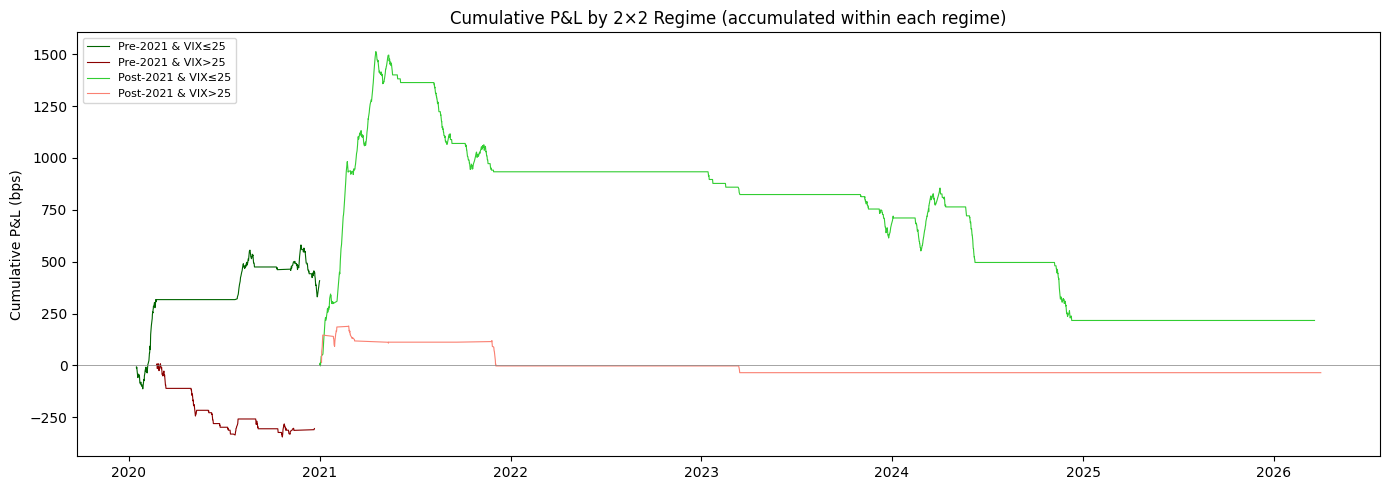

In [18]:
# Separate cumulative P&L for each 2x2 regime
colors_2x2 = {
    'Pre-2021 & VIX≤25': 'darkgreen',
    'Pre-2021 & VIX>25': 'darkred',
    'Post-2021 & VIX≤25': 'limegreen',
    'Post-2021 & VIX>25': 'salmon',
}

fig, ax = plt.subplots(figsize=(14, 5))
for regime, color in colors_2x2.items():
    sub = agg[agg['regime_2x2'] == regime].copy()
    sub['cum'] = sub['total_pnl'].cumsum() * 10_000
    ax.plot(sub['timestamp'], sub['cum'], color=color, linewidth=0.8, label=regime)

ax.axhline(0, color='grey', linewidth=0.5)
ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Cumulative P&L by 2×2 Regime (accumulated within each regime)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## 18. Summary Statistics Table

In [19]:
# Final summary: load regime_analysis.csv and display full table
regime_df = pd.read_csv('../output/regime_analysis.csv')
cols = ['regime', 'sharpe', 'annual_bps', 'total_bps', 'max_dd_bps', 'win_rate',
        'pct_time_in_carry', 'n_periods', 'funding_bps', 'cost_bps']
summary = regime_df[cols].copy()
summary.columns = ['Regime', 'Sharpe', 'Ann bps/yr', 'Total bps', 'Max DD bps',
                    'Win Rate', '% in Carry', 'N Periods', 'Funding bps', 'Cost bps']
summary

,Regime,Sharpe,Ann bps/yr,Total bps,Max DD bps,Win Rate,% in Carry,N Periods,Funding bps,Cost bps
0,Full Sample,0.370185,46.020928,285.638451,-1448.577710,0.611960,0.221291,6801,6111.637533,-5954.559199
1,Pre-2021,0.610503,108.231568,104.008982,-343.694232,0.611452,0.464387,1053,1979.423228,-1910.366216
2,Post-2021,0.309342,34.624303,181.629469,-1448.577710,0.612205,0.176757,5748,4132.214305,-4044.192984
3,VIX <= 25,1.016685,128.361295,624.849781,-1295.605694,0.633781,0.237533,5334,5258.462838,-4735.720130
4,VIX > 25,-2.173651,-253.367972,-339.211330,-353.375187,0.495798,0.162236,1467,853.174695,-1218.839070
5,Pre-2021 & VIX <= 25,4.686913,1104.501603,408.234679,-250.242320,0.658385,0.795062,405,1478.660922,-1082.307312
6,Pre-2021 & VIX > 25,-4.139599,-514.437203,-304.225697,-353.375187,0.520958,0.257716,648,500.762306,-828.058904
7,Post-2021 & VIX <= 25,0.428835,48.155001,216.615102,-1295.605694,0.625397,0.191722,4929,3779.801916,-3653.412818
8,Post-2021 & VIX > 25,-0.426763,-46.807701,-34.985633,-224.984125,0.436620,0.086691,819,352.412389,-390.780166
